# SP500 Options Daily Trading Strategy

In [16]:
import yaml, requests, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm, skew
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Optional

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 80)

with open(Path("../data_preparation/data_apiKey/config.yaml")) as f:
    cfg = yaml.safe_load(f)

FMP_KEY = cfg["keys"]["fmp_api_key"]
client = None
try:
    from massive import RESTClient
    client = RESTClient(api_key=cfg["keys"]["polygon_api_key"])
except:
    pass

In [17]:
UNIVERSE = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA",
    "JPM", "V", "UNH", "JNJ", "PG", "HD", "BAC", "XOM",
    "MA", "COST", "ABBV", "CRM", "AMD", "NFLX", "LLY",
    "ADBE", "PEP", "AVGO", "TMO", "MRK", "ORCL", "WMT", "CSCO"
]

START, END = "2023-01-01", "2025-12-01"
INITIAL_CAPITAL = 2_000_000
RF = 0.045

In [18]:
def fetch_ohlcv(ticker, start, end):
    url = f"https://financialmodelingprep.com/stable/historical-price-eod/full?symbol={ticker}&from={start}&to={end}&apikey={FMP_KEY}"
    try:
        data = requests.get(url).json()
        if not data:
            return None
        df = pd.DataFrame(data)
        df["date"] = pd.to_datetime(df["date"])
        return df.sort_values("date").set_index("date")[["open","high","low","close","volume"]]
    except:
        return None

raw = {}
for t in UNIVERSE:
    raw[t] = fetch_ohlcv(t, START, END)
    time.sleep(0.12)

valid = [t for t in UNIVERSE if raw[t] is not None and len(raw[t]) > 100]
close_df = pd.DataFrame({t: raw[t]["close"] for t in valid}).dropna()
high_df = pd.DataFrame({t: raw[t]["high"] for t in valid}).reindex(close_df.index)
low_df = pd.DataFrame({t: raw[t]["low"] for t in valid}).reindex(close_df.index)
open_df = pd.DataFrame({t: raw[t]["open"] for t in valid}).reindex(close_df.index)
vol_df = pd.DataFrame({t: raw[t]["volume"] for t in valid}).reindex(close_df.index)

spy_raw = fetch_ohlcv("SPY", START, END)

print(f"{close_df.shape[0]} trading days, {close_df.shape[1]} tickers loaded")
close_df

731 trading days, 30 tickers loaded


,AAPL,MSFT,GOOGL,AMZN,META,NVDA,TSLA,JPM,V,UNH,...,NFLX,LLY,ADBE,PEP,AVGO,TMO,MRK,ORCL,WMT,CSCO
date,,,,,,,,,,,,,,,,,,,,,
2023-01-03,125.07,239.58,89.12,85.82,124.74,14.32,108.10,135.12,207.39,518.64,...,29.50,364.99,336.92,179.41,55.35,553.18,111.14,83.72,47.87,47.94
2023-01-04,126.36,229.10,88.08,85.14,127.37,14.75,113.64,136.38,212.61,504.50,...,30.94,363.10,341.41,178.97,56.02,561.92,112.08,84.48,47.92,47.55
2023-01-05,125.02,222.31,86.20,83.12,126.94,14.27,110.34,135.35,211.11,489.96,...,30.97,358.92,328.44,177.10,55.50,556.94,113.64,84.31,47.76,46.88
2023-01-06,129.62,224.93,87.34,86.08,130.02,14.86,113.06,137.94,217.75,490.00,...,31.56,362.94,332.75,181.10,58.84,535.00,114.84,85.66,48.93,48.32
2023-01-09,130.15,227.12,88.02,87.36,129.47,15.63,119.77,137.37,218.60,490.06,...,31.52,349.83,341.98,179.33,57.69,546.09,110.38,86.42,48.32,48.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,275.92,474.00,318.58,226.28,613.05,182.55,417.78,298.00,329.30,319.05,...,106.97,1070.16,318.73,145.50,377.96,586.07,100.40,200.28,104.06,76.24
2025-11-25,276.97,476.99,323.44,229.67,636.22,177.82,419.40,303.00,334.53,326.28,...,104.40,1109.94,319.55,146.11,385.03,597.78,105.66,197.03,107.00,76.32
2025-11-26,277.55,485.50,319.95,229.16,633.61,180.26,426.58,307.64,333.79,329.71,...,106.14,1104.34,317.52,147.98,397.57,593.25,104.63,204.96,109.10,76.07


In [19]:
def _rsi(s, n=14):
    d = s.diff()
    up = d.clip(lower=0).rolling(n).mean()
    dn = -d.clip(upper=0).rolling(n).mean()
    return 100 - 100 / (1 + up / dn)

def _obv(close, volume):
    sign = np.sign(close.diff()).fillna(0)
    return (sign * volume).cumsum()

def _skewness(ret, window=20):
    return ret.rolling(window).apply(lambda x: skew(x, nan_policy="omit"), raw=False)

def build_features(close, high, low, opn, volume):
    ret1 = close.pct_change()
    ret5 = close.pct_change(5)
    ret20 = close.pct_change(20)

    f = {}

    f["rsi14"] = close.apply(lambda x: _rsi(x, 14))
    f["rsi5"] = close.apply(lambda x: _rsi(x, 5))

    ma10 = close.rolling(10).mean()
    ma30 = close.rolling(30).mean()
    f["sma_cross"] = (ma10 - ma30) / close

    f["mom5"] = ret5
    f["mom20"] = ret20

    rvol20 = ret1.rolling(20).std() * np.sqrt(252)
    rvol60 = ret1.rolling(60).std() * np.sqrt(252)
    f["rvol"] = rvol20
    f["vol_ratio"] = rvol20 / rvol60
    f["vol_pctrank"] = rvol20.rolling(120, min_periods=60).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False
    )

    price_dir = np.sign(ret5)
    vol_trend = (volume.rolling(5).mean() / volume.rolling(20).mean() - 1)
    f["vp_div"] = -price_dir * np.sign(vol_trend)

    f["xs_ret_rank"] = ret5.rank(axis=1, pct=True)
    f["xs_vol_rank"] = rvol20.rank(axis=1, pct=True)

    ma20 = close.rolling(20).mean()
    std20 = close.rolling(20).std()
    f["zscore"] = (close - ma20) / std20

    bollinger_upper = ma20 + 2 * std20
    bollinger_lower = ma20 - 2 * std20
    f["bb_pct"] = (close - bollinger_lower) / (bollinger_upper - bollinger_lower)

    f["gap"] = (opn - close.shift(1)) / close.shift(1)

    atr14 = pd.DataFrame(np.maximum(
        high - low,
        np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1)))
    ), index=close.index, columns=close.columns).rolling(14).mean()
    f["atr_pct"] = atr14 / close

    f["ret_skew"] = _skewness(ret1, 30)

    obv_df = pd.DataFrame({c: _obv(close[c], volume[c]) for c in close.columns})
    f["obv_slope"] = obv_df.diff(10) / obv_df.rolling(30).std()

    f["high_pct"] = close / close.rolling(60).max()

    return f

feat = build_features(close_df, high_df, low_df, open_df, vol_df)
print(f"{len(feat)} features built")
for k, v in feat.items():
    print(f"  {k}: mean={v.mean().mean():.4f}, nan%={v.isna().mean().mean()*100:.1f}%")

18 features built
  rsi14: mean=53.7892, nan%=1.9%
  rsi5: mean=53.9789, nan%=0.7%
  sma_cross: mean=0.0068, nan%=4.0%
  mom5: mean=0.0056, nan%=0.7%
  mom20: mean=0.0218, nan%=2.7%
  rvol: mean=0.2763, nan%=2.7%
  vol_ratio: mean=0.9706, nan%=8.2%
  vol_pctrank: mean=0.5064, nan%=10.8%
  vp_div: mean=0.0440, nan%=2.6%
  xs_ret_rank: mean=0.5167, nan%=0.7%
  xs_vol_rank: mean=0.5167, nan%=2.7%
  zscore: mean=0.2338, nan%=2.6%
  bb_pct: mean=0.5584, nan%=2.6%
  gap: mean=0.0005, nan%=0.1%
  atr_pct: mean=0.0241, nan%=1.9%
  ret_skew: mean=0.0178, nan%=4.1%
  obv_slope: mean=0.1762, nan%=4.0%
  high_pct: mean=0.9352, nan%=8.1%


In [20]:
def generate_signals(feat):
    idx = feat["rsi14"].index
    cols = feat["rsi14"].columns
    sc = pd.DataFrame(0.0, index=idx, columns=cols)

    rsi = feat["rsi14"]
    sc += ((rsi < 30).astype(float) * 1.5)
    sc -= ((rsi > 70).astype(float) * 1.5)
    sc += ((rsi >= 30) & (rsi < 45)).astype(float) * 0.3
    sc -= ((rsi > 55) & (rsi <= 70)).astype(float) * 0.3

    sc += np.sign(feat["sma_cross"]) * 0.8

    sc += feat["mom5"].clip(-0.15, 0.15) * 4.0

    zs = feat["zscore"]
    sc += (zs < -2).astype(float) * 1.2
    sc -= (zs > 2).astype(float) * 1.2

    sc += (feat["xs_ret_rank"] - 0.5) * 1.5

    sc += feat["vp_div"] * 0.6

    sc -= np.sign(feat["gap"]) * (feat["gap"].abs() > 0.01).astype(float) * 0.6

    sk = feat["ret_skew"].fillna(0).clip(-3, 3)
    sc -= sk * 0.25

    obv_s = feat["obv_slope"].fillna(0).clip(-3, 3)
    sc += obv_s * 0.3

    hp = feat["high_pct"].fillna(1)
    sc += (hp > 0.95).astype(float) * 0.4
    sc -= (hp < 0.75).astype(float) * 0.3

    bb = feat["bb_pct"].fillna(0.5)
    sc += (bb < 0.05).astype(float) * 0.8
    sc -= (bb > 0.95).astype(float) * 0.8

    rsi5 = feat["rsi5"]
    sc += ((rsi5 < 20) & (rsi > 35)).astype(float) * 0.7  # short-term oversold but mid-term ok

    vol_scaling = 1 / (1 + feat["atr_pct"].fillna(0.02) * 20)
    sc = sc * vol_scaling

    direction = sc.clip(-5, 5) / 5.0

    vr = feat["vol_pctrank"].fillna(0.5)
    regime = pd.DataFrame(0, index=idx, columns=cols, dtype=float)
    regime[vr > 0.65] = 1    # high IV -> sell premium
    regime[vr < 0.35] = -1   # low IV -> buy premium

    return direction, regime

dir_sig, iv_regime = generate_signals(feat)
dir_sig = dir_sig.iloc[120:].fillna(0)
iv_regime = iv_regime.reindex(dir_sig.index).fillna(0)

print(f"Signal range: [{dir_sig.min().min():.3f}, {dir_sig.max().max():.3f}]")
print(f"Avg daily active (|sig|>0.12): {(dir_sig.abs() > 0.12).sum(axis=1).mean():.1f}")
print(f"Pct days any high-IV: {(iv_regime > 0).any(axis=1).mean()*100:.1f}%")

Signal range: [-0.676, 0.739]
Avg daily active (|sig|>0.12): 15.2
Pct days any high-IV: 100.0%


In [21]:
def bs_price(S, K, T, r, sigma, opt_type):
    if T <= 1e-6:
        return max(S - K, 0) if opt_type == "call" else max(K - S, 0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if opt_type == "call":
        return S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    else:
        return K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def bs_delta(S, K, T, r, sigma, opt_type):
    if T <= 1e-6:
        if opt_type == "call":
            return 1.0 if S > K else 0.0
        else:
            return -1.0 if S < K else 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    if opt_type == "call":
        return norm.cdf(d1)
    else:
        return norm.cdf(d1) - 1

def bs_gamma(S, K, T, r, sigma):
    if T <= 1e-6:
        return 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_theta(S, K, T, r, sigma, opt_type):
    if T <= 1e-6:
        return 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    term1 = -S * norm.pdf(d1) * sigma / (2*np.sqrt(T))
    if opt_type == "call":
        return (term1 - r*K*np.exp(-r*T)*norm.cdf(d2)) / 252
    else:
        return (term1 + r*K*np.exp(-r*T)*norm.cdf(-d2)) / 252


@dataclass
class Position:
    ticker: str
    opt_type: str       # "call" or "put"
    side: int           # +1 long, -1 short
    K: float
    entry_date: pd.Timestamp
    dte_at_entry: int
    entry_price: float
    iv: float
    n_contracts: int
    entry_spot: float

    def current_dte(self, today):
        elapsed = np.busday_count(
            self.entry_date.date(), today.date()
        )
        return max(self.dte_at_entry - elapsed, 0)

    def mark(self, S, today):
        T = self.current_dte(today) / 252
        return bs_price(S, self.K, T, RF, self.iv, self.opt_type)

    def pnl_per_contract(self, S, today):
        mtm = self.mark(S, today)
        return self.side * (mtm - self.entry_price) * 100

    def total_pnl(self, S, today):
        return self.pnl_per_contract(S, today) * self.n_contracts

    def intrinsic(self, S):
        if self.opt_type == "call":
            return max(S - self.K, 0)
        return max(self.K - S, 0)

In [22]:
def run_backtest(close_df, dir_sig, iv_regime, feat,
                 sig_thresh=0.12, dte_target=30, alloc_per_trade=6000,
                 max_positions=40, max_per_ticker=3,
                 profit_target=0.60, stop_loss=-0.45, dte_exit=3):

    dates = dir_sig.index
    tickers = dir_sig.columns
    positions: list[Position] = []
    trade_log = []
    daily_pnl = []
    daily_nav = []
    nav = INITIAL_CAPITAL

    for i in range(1, len(dates)):
        dt = dates[i]
        prev = dates[i-1]
        realized_today = 0.0
        unrealized_today = 0.0

        closed_idx = []
        for pi, pos in enumerate(positions):
            S = close_df.loc[dt, pos.ticker] if pos.ticker in close_df.columns else None
            if S is None or pd.isna(S):
                closed_idx.append(pi)
                continue

            dte_now = pos.current_dte(dt)
            pnl_pct = pos.pnl_per_contract(S, dt) / (pos.entry_price * 100) if pos.entry_price > 0 else 0
            cur_sig = dir_sig.loc[prev, pos.ticker] if prev in dir_sig.index else 0

            close_reason = None

            if dte_now <= dte_exit:
                intrinsic = pos.intrinsic(S)
                if pos.side == 1 and intrinsic > 0:
                    close_reason = "exercise"
                elif pos.side == -1 and intrinsic > 0:
                    close_reason = "assignment"
                else:
                    close_reason = "expire_otm"

            elif pnl_pct >= profit_target:
                close_reason = "take_profit"
            elif pnl_pct <= stop_loss:
                close_reason = "stop_loss"
            elif pos.side == 1 and pos.opt_type == "call" and cur_sig < -0.15:
                close_reason = "signal_reversal"
            elif pos.side == 1 and pos.opt_type == "put" and cur_sig > 0.15:
                close_reason = "signal_reversal"
            elif pos.side == -1 and dte_now < 10 and pnl_pct > 0.3:
                close_reason = "early_close_short"

            if close_reason:
                total = pos.total_pnl(S, dt)
                if close_reason == "exercise" and pos.side == 1:
                    total = pos.intrinsic(S) * 100 * pos.n_contracts - pos.entry_price * 100 * pos.n_contracts
                elif close_reason == "assignment" and pos.side == -1:
                    total = pos.entry_price * 100 * pos.n_contracts - pos.intrinsic(S) * 100 * pos.n_contracts
                elif close_reason == "expire_otm":
                    if pos.side == 1:
                        total = -pos.entry_price * 100 * pos.n_contracts
                    else:
                        total = pos.entry_price * 100 * pos.n_contracts

                realized_today += total
                trade_log.append({
                    "entry_date": pos.entry_date, "exit_date": dt,
                    "ticker": pos.ticker, "type": pos.opt_type,
                    "side": "long" if pos.side == 1 else "short",
                    "K": pos.K, "entry_spot": pos.entry_spot,
                    "exit_spot": S, "entry_px": round(pos.entry_price, 2),
                    "n": pos.n_contracts, "pnl": round(total, 2),
                    "reason": close_reason, "hold_days": np.busday_count(pos.entry_date.date(), dt.date()),
                    "iv": pos.iv,
                })
                closed_idx.append(pi)
            else:
                unrealized_today += pos.total_pnl(S, dt)

        for ci in sorted(closed_idx, reverse=True):
            positions.pop(ci)

        ticker_count = defaultdict(int)
        for p in positions:
            ticker_count[p.ticker] += 1

        if len(positions) < max_positions:
            candidates = []
            for t in tickers:
                if ticker_count[t] >= max_per_ticker:
                    continue
                sig = dir_sig.loc[prev, t]
                if abs(sig) < sig_thresh:
                    continue
                candidates.append((t, sig))

            candidates.sort(key=lambda x: abs(x[1]), reverse=True)
            slots = max_positions - len(positions)
            candidates = candidates[:slots]

            for t, sig in candidates:
                S = close_df.loc[prev, t]
                if pd.isna(S):
                    continue

                rv = feat["rvol"].loc[prev, t] if not pd.isna(feat["rvol"].loc[prev, t]) else 0.25
                iv = np.clip(rv * 1.15, 0.08, 2.0)  # rough IV markup
                regime = iv_regime.loc[prev, t]

                if regime > 0:
                    side = -1
                    if sig > 0:
                        opt_type = "put"
                        K = round(S * 0.97)
                    else:
                        opt_type = "call"
                        K = round(S * 1.03)
                else:
                    side = 1
                    if sig > 0:
                        opt_type = "call"
                        K = round(S * 1.01)
                    else:
                        opt_type = "put"
                        K = round(S * 0.99)

                T0 = dte_target / 252
                px = bs_price(S, K, T0, RF, iv, opt_type)
                if px < 0.10:
                    continue

                n = max(1, int(alloc_per_trade * abs(sig) / (px * 100)))
                if n > 20:
                    n = 20

                positions.append(Position(
                    ticker=t, opt_type=opt_type, side=side,
                    K=K, entry_date=dt, dte_at_entry=dte_target,
                    entry_price=px, iv=iv, n_contracts=n, entry_spot=S,
                ))

        nav = INITIAL_CAPITAL + realized_today + unrealized_today
        daily_pnl.append({"date": dt, "realized": realized_today, "nav": nav})

    pnl_df = pd.DataFrame(daily_pnl).set_index("date")
    log_df = pd.DataFrame(trade_log)
    return pnl_df, log_df

pnl_df, trade_log = run_backtest(close_df, dir_sig, iv_regime, feat)
print(f"Completed trades: {len(trade_log)}")
if len(trade_log) > 0:
    print(f"Long: {(trade_log['side']=='long').sum()}, Short: {(trade_log['side']=='short').sum()}")
    print(f"Calls: {(trade_log['type']=='call').sum()}, Puts: {(trade_log['type']=='put').sum()}")
    print(f"\nExit reasons:")
    print(trade_log["reason"].value_counts().to_string())

Completed trades: 3748
Long: 2538, Short: 1210
Calls: 2147, Puts: 1601

Exit reasons:
reason
stop_loss            1587
take_profit          1474
signal_reversal       581
early_close_short      89
assignment             12
exercise                5


In [23]:
spy_ret = spy_raw["close"].pct_change().reindex(pnl_df.index).fillna(0)
strat_ret = pnl_df["nav"].pct_change().fillna(0)

cum_strat = (1 + strat_ret).cumprod()
cum_bench = (1 + spy_ret).cumprod()

def sharpe(rets, rf_annual=0.045):
    rf_d = rf_annual / 252
    ex = rets - rf_d
    return np.sqrt(252) * ex.mean() / ex.std() if ex.std() > 0 else 0

def max_dd(cum):
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd.min()

def sortino(rets, rf_annual=0.045):
    rf_d = rf_annual / 252
    ex = rets - rf_d
    downside = ex[ex < 0].std()
    return np.sqrt(252) * ex.mean() / downside if downside > 0 else 0

def calmar(rets, cum):
    ann_ret = (cum.iloc[-1]) ** (252 / len(rets)) - 1
    mdd = abs(max_dd(cum))
    return ann_ret / mdd if mdd > 0 else 0

strat_sharpe = sharpe(strat_ret)
bench_sharpe = sharpe(spy_ret)
excess_ret = strat_ret - spy_ret
excess_sharpe = sharpe(excess_ret, rf_annual=0)

total_ret = cum_strat.iloc[-1] - 1
ann_ret = (1 + total_ret) ** (252 / len(strat_ret)) - 1

print("=" * 50)
print(f"  Strategy Total Return:   {total_ret*100:>8.2f}%")
print(f"  Strategy Ann. Return:    {ann_ret*100:>8.2f}%")
print(f"  Benchmark Total Return:  {(cum_bench.iloc[-1]-1)*100:>8.2f}%")
print(f"{'='*50}")
print(f"  Strategy Sharpe:         {strat_sharpe:>8.3f}")
print(f"  Benchmark Sharpe:        {bench_sharpe:>8.3f}")
print(f"  Excess Sharpe (vs SPY):  {excess_sharpe:>8.3f}")
print(f"  Sortino:                 {sortino(strat_ret):>8.3f}")
print(f"  Calmar:                  {calmar(strat_ret, cum_strat):>8.3f}")
print(f"{'='*50}")
print(f"  Strategy Max DD:         {max_dd(cum_strat)*100:>8.2f}%")
print(f"  Benchmark Max DD:        {max_dd(cum_bench)*100:>8.2f}%")
print(f"  Total Completed Trades:  {len(trade_log):>8d}")
print(f"  Win Rate:                {(trade_log['pnl']>0).mean()*100:>8.1f}%")
print(f"  Avg PnL / Trade:        ${trade_log['pnl'].mean():>8.2f}")
print(f"  Median PnL / Trade:     ${trade_log['pnl'].median():>8.2f}")
print(f"  Avg Hold Days:           {trade_log['hold_days'].mean():>8.1f}")
print(f"  Best Trade:             ${trade_log['pnl'].max():>8.0f}")
print(f"  Worst Trade:            ${trade_log['pnl'].min():>8.0f}")
print("=" * 50)

  Strategy Total Return:      -0.25%
  Strategy Ann. Return:       -0.10%
  Benchmark Total Return:     55.96%
  Strategy Sharpe:           -0.829
  Benchmark Sharpe:           0.961
  Excess Sharpe (vs SPY):    -1.383
  Sortino:                   -1.301
  Calmar:                    -0.031
  Strategy Max DD:            -3.36%
  Benchmark Max DD:          -19.00%
  Total Completed Trades:      3748
  Win Rate:                    49.6%
  Avg PnL / Trade:        $  143.28
  Median PnL / Trade:     $  -25.84
  Avg Hold Days:                6.7
  Best Trade:             $    9372
  Worst Trade:            $   -9398


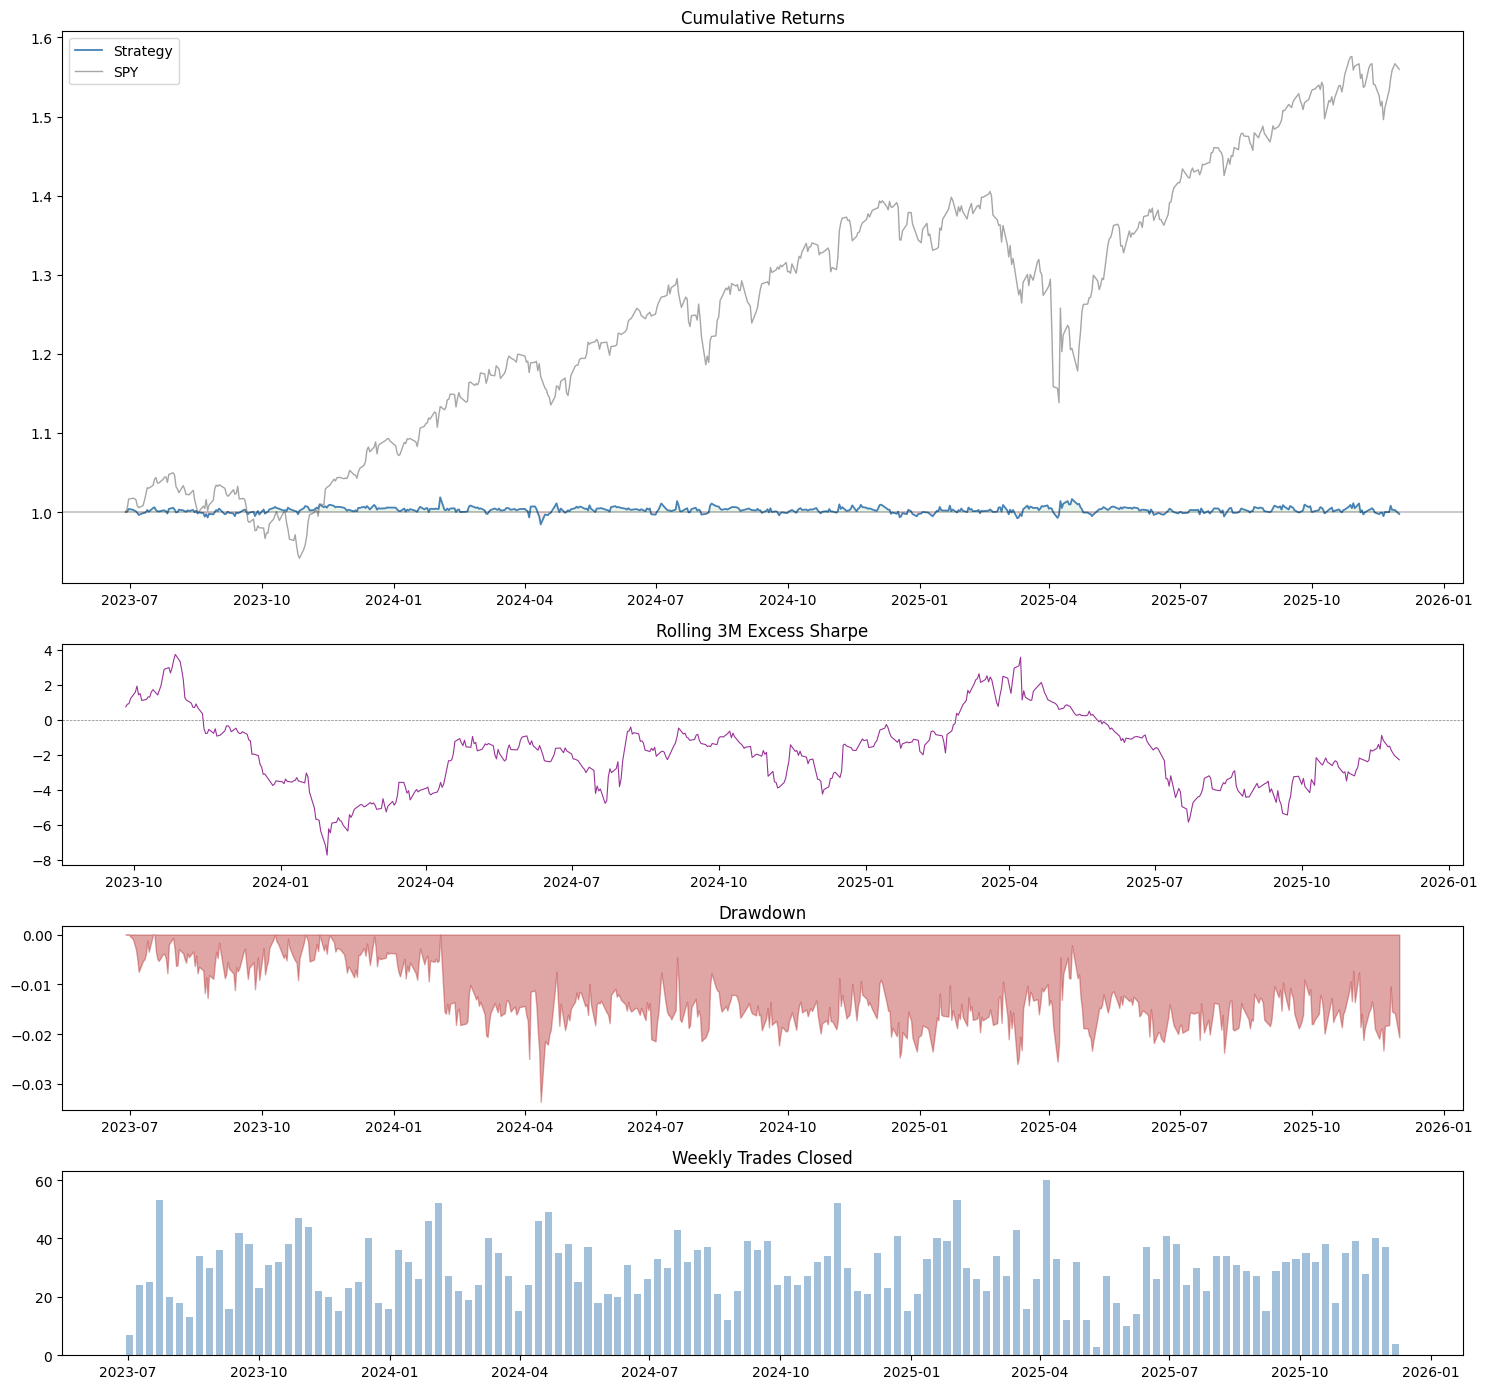

In [24]:
fig, axes = plt.subplots(4, 1, figsize=(15, 14), height_ratios=[3, 1.2, 1, 1])

axes[0].plot(cum_strat.index, cum_strat, label="Strategy", linewidth=1.3, color="steelblue")
axes[0].plot(cum_bench.index, cum_bench, label="SPY", linewidth=1.0, alpha=0.7, color="gray")
axes[0].fill_between(cum_strat.index, cum_strat, 1, where=cum_strat > 1, alpha=0.08, color="green")
axes[0].fill_between(cum_strat.index, cum_strat, 1, where=cum_strat < 1, alpha=0.08, color="red")
axes[0].axhline(1, color="black", linewidth=0.3)
axes[0].set_title("Cumulative Returns")
axes[0].legend(loc="upper left")

roll_sr = excess_ret.rolling(63).apply(
    lambda x: np.sqrt(252)*x.mean()/x.std() if x.std()>0 else 0
)
axes[1].plot(roll_sr.index, roll_sr, color="purple", linewidth=0.8, alpha=0.8)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.5)
axes[1].set_title("Rolling 3M Excess Sharpe")

dd = (cum_strat - cum_strat.cummax()) / cum_strat.cummax()
axes[2].fill_between(dd.index, dd, 0, color="firebrick", alpha=0.4)
axes[2].set_title("Drawdown")

if len(trade_log) > 0:
    tl = trade_log.copy()
    tl["exit_date"] = pd.to_datetime(tl["exit_date"])
    daily_count = tl.set_index("exit_date").resample("W")["pnl"].count()
    axes[3].bar(daily_count.index, daily_count.values, width=5, alpha=0.5, color="steelblue")
    axes[3].set_title("Weekly Trades Closed")

plt.tight_layout()
plt.show()

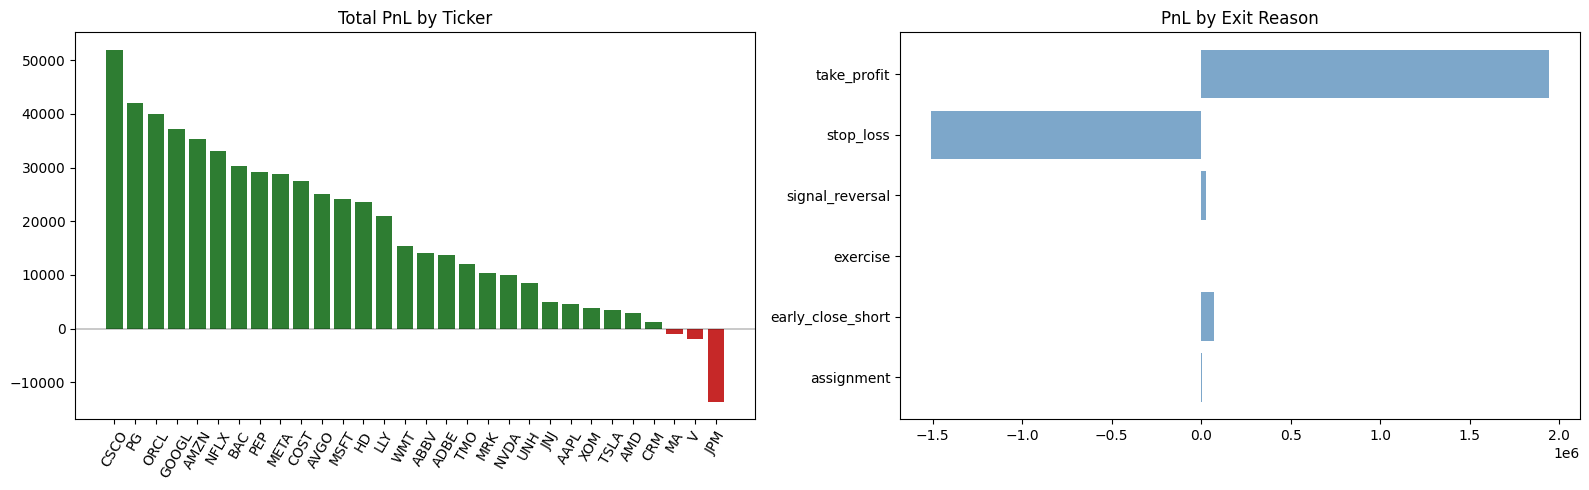

,total_pnl,avg_pnl,trades
ticker,,,
CSCO,51898.57,353.051497,147
PG,41979.38,306.418832,137
ORCL,39884.25,343.829741,116
GOOGL,37227.60,310.230000,120
AMZN,35217.24,308.923158,114
NFLX,33005.18,297.343964,111
BAC,30191.21,234.040388,129
PEP,29131.38,225.824651,129
META,28736.48,271.098868,106


In [25]:
by_ticker = trade_log.groupby("ticker")["pnl"].agg(["sum","mean","count"])
by_ticker.columns = ["total_pnl","avg_pnl","trades"]
by_ticker = by_ticker.sort_values("total_pnl", ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

colors = ["#2e7d32" if x > 0 else "#c62828" for x in by_ticker["total_pnl"]]
ax1.bar(by_ticker.index, by_ticker["total_pnl"], color=colors)
ax1.set_title("Total PnL by Ticker")
ax1.tick_params(axis="x", rotation=60)
ax1.axhline(0, color="black", linewidth=0.3)

by_reason = trade_log.groupby("reason")["pnl"].agg(["sum","mean","count"])
ax2.barh(by_reason.index, by_reason["sum"], color="steelblue", alpha=0.7)
ax2.set_title("PnL by Exit Reason")

plt.tight_layout()
plt.show()

by_ticker

=== Side Breakdown ===
           total         avg  count          std
side                                            
long   310700.86  122.419567   2538  1202.811792
short  226297.69  187.022884   1210  1366.983918

=== Contract Type ===
          total         avg  count          std
type                                           
call  299245.27  139.378328   2147  1269.222862
put   237753.28  148.502986   1601  1243.962176

=== Side x Type ===
                total         avg  count
side  type                              
long  call  253766.84  148.662472   1707
      put    56934.02   68.512659    831
short call   45478.43  103.360068    440
      put   180819.26  234.830208    770


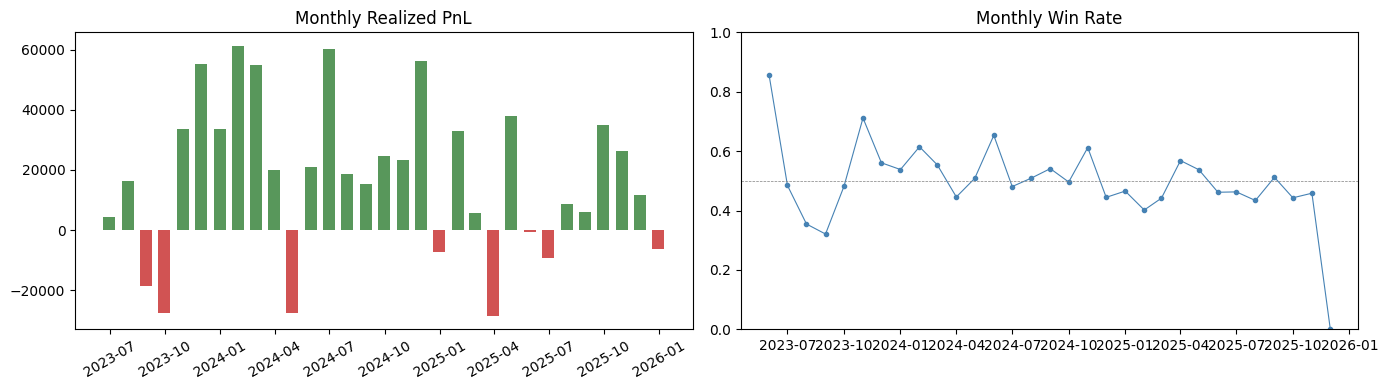

In [26]:
print("=== Side Breakdown ===")
by_side = trade_log.groupby("side")[["pnl"]].agg(["sum","mean","count","std"])
by_side.columns = ["total","avg","count","std"]
print(by_side)

print("\n=== Contract Type ===")
by_type = trade_log.groupby("type")[["pnl"]].agg(["sum","mean","count","std"])
by_type.columns = ["total","avg","count","std"]
print(by_type)

print("\n=== Side x Type ===")
by_st = trade_log.groupby(["side","type"])[["pnl"]].agg(["sum","mean","count"])
by_st.columns = ["total","avg","count"]
print(by_st)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

monthly = pnl_df["realized"].resample("ME").sum()
colors_m = ["#2e7d32" if x > 0 else "#c62828" for x in monthly]
ax1.bar(monthly.index, monthly.values, width=20, color=colors_m, alpha=0.8)
ax1.set_title("Monthly Realized PnL")
ax1.tick_params(axis="x", rotation=30)

if len(trade_log) > 0:
    tl2 = trade_log.copy()
    tl2["exit_date"] = pd.to_datetime(tl2["exit_date"])
    tl2["month"] = tl2["exit_date"].dt.to_period("M")
    win_rate_monthly = tl2.groupby("month")["pnl"].apply(lambda x: (x>0).mean())
    ax2.plot(win_rate_monthly.index.to_timestamp(), win_rate_monthly.values,
             marker="o", markersize=3, linewidth=0.8, color="steelblue")
    ax2.axhline(0.5, color="gray", linestyle="--", linewidth=0.5)
    ax2.set_title("Monthly Win Rate")
    ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Live Validation 

In [27]:
latest_sig = dir_sig.iloc[-1].sort_values()
iv_latest = iv_regime.iloc[-1]

bullish = latest_sig[latest_sig > 0.12]
bearish = latest_sig[latest_sig < -0.12]

print("=== Today's Signals ===\n")
print("BULLISH:")
for t, s in bullish.sort_values(ascending=False).items():
    regime = "SELL put" if iv_latest[t] > 0 else "BUY call"
    print(f"  {t:>6s}  sig={s:+.3f}  ->  {regime}")

print("\nBEARISH:")
for t, s in bearish.items():
    regime = "SELL call" if iv_latest[t] > 0 else "BUY put"
    print(f"  {t:>6s}  sig={s:+.3f}  ->  {regime}")

=== Today's Signals ===

BULLISH:
    AVGO  sig=+0.244  ->  SELL put
    META  sig=+0.237  ->  SELL put
    TSLA  sig=+0.220  ->  BUY call
     BAC  sig=+0.199  ->  BUY call
   GOOGL  sig=+0.160  ->  SELL put
     PEP  sig=+0.159  ->  BUY call

BEARISH:
     WMT  sig=-0.365  ->  SELL call
      MA  sig=-0.247  ->  SELL call
      PG  sig=-0.196  ->  SELL call
     CRM  sig=-0.195  ->  SELL call
     LLY  sig=-0.176  ->  BUY put
    MSFT  sig=-0.140  ->  SELL call


In [28]:
if client is not None and len(pd.concat([bullish, bearish])) > 0:
    top = pd.concat([bullish, bearish]).abs().idxmax()
    spot = close_df[top].iloc[-1]

    chain_data = []
    for o in client.list_snapshot_options_chain(
        top,
        params={
            "expiration_date.gte": "2026-04-01",
            "expiration_date.lte": "2026-04-30",
            "strike_price.gte": spot * 0.95,
            "strike_price.lte": spot * 1.05,
        },
    ):
        chain_data.append(o)

    rows = []
    for o in chain_data:
        if o.details:
            rows.append({
                "type": o.details.contract_type,
                "strike": o.details.strike_price,
                "exp": o.details.expiration_date,
                "iv": round(o.implied_volatility, 4) if o.implied_volatility else None,
                "oi": o.open_interest,
                "last": o.day.close if o.day else None,
                "vol": o.day.volume if o.day else None,
            })
    chain_df = pd.DataFrame(rows).sort_values(["type","strike"])
    print(f"\nLive ATM chain for {top} (spot={spot:.2f}):")
    chain_df
else:
    print("No Massive client or no signals")


Live ATM chain for WMT (spot=111.53):


### Position Export

In [ ]:
import os, requests as _req
from datetime import datetime as _dt

def _fmp_ids(tickers, api_key):
    out = {}
    for t in tickers:
        try:
            r = _req.get(f"https://financialmodelingprep.com/stable/profile?symbol={t}&apikey={api_key}", timeout=10)
            d = r.json()
            out[t] = (d[0].get("cusip","") if d else "", d[0].get("isin","") if d else "")
        except Exception:
            out[t] = ("", "")
    return out

day = _dt.now().strftime("%Y%m%d")
active = latest_sig[latest_sig.abs() > 0.12]
tks = active.index.tolist()
wts = active.abs().values / active.abs().values.sum() * np.sign(active.values)
ids = _fmp_ids(tks, FMP_KEY)

df_pos = pd.DataFrame({
    "ticker": tks,
    "cusip": [ids[t][0] for t in tks],
    "isin": [ids[t][1] for t in tks],
    "weight": wts,
    "order_time": "MOC",
    "order_type": "default"
})

out_dir = f"../execution_main/trading_log/{day}"
os.makedirs(out_dir, exist_ok=True)
df_pos.to_csv(f"{out_dir}/strategy_optionTrade_weight.csv", index=False)
print(f"→ {out_dir}/strategy_optionTrade_weight.csv  ({len(df_pos)} rows)")
df_pos